In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Path to your dataset folder
path = "/content/drive/MyDrive/"

# Load LIAR dataset
train = pd.read_csv(path + "train.tsv", sep="\t", header=None)
test = pd.read_csv(path + "test.tsv", sep="\t", header=None)
valid = pd.read_csv(path + "valid.tsv", sep="\t", header=None)

# Only keep relevant columns: label (1) and text (2)
df = train[[1, 2]].copy()
df.columns = ['label', 'text']

print(df.head())
print(df['label'].value_counts())

Mounted at /content/drive
         label                                               text
0        false  Says the Annies List political group supports ...
1    half-true  When did the decline of coal start? It started...
2  mostly-true  Hillary Clinton agrees with John McCain "by vo...
3        false  Health care reform legislation is likely to ma...
4    half-true  The economic turnaround started at the end of ...
label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64


In [ ]:
import re
from bs4 import BeautifulSoup

# Combine title + text if available, otherwise just use text
# For LIAR dataset, we usually just have 'text'
# df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')  # if title exists
df['content_clean'] = df['text'].apply(lambda x: str(x))  # ensure all are strings

# Clean text function
def clean_text(text):
    text = BeautifulSoup(text, "lxml").get_text()  # remove HTML
    text = re.sub(r"@[A-Za-z0-9]+", " ", text)    # remove mentions
    text = re.sub(r"https?://[A-Za-z0-9./]+", " ", text)  # remove links
    text = re.sub(r"[^a-zA-Z.!?']+", " ", text)   # keep letters and punctuation
    text = re.sub(r" +", " ", text)               # remove extra spaces
    return text.strip()

df['content_clean'] = df['content_clean'].apply(clean_text)

# Map LIAR labels to binary
label_map = {
    'pants-fire': 0,
    'false': 0,
    'barely-true': 0,
    'half-true': 1,
    'mostly-true': 1,
    'true': 1
}

df['label'] = df['label'].map(label_map)

# Drop rows with NaN labels (unexpected values) or empty content
df = df.dropna(subset=['label'])
df = df[df['content_clean'].str.strip() != '']

# Verify
print(df[['content_clean','label']].head())
print(df['label'].value_counts())



                                       content_clean  label
0  Says the Annies List political group supports ...      0
1  When did the decline of coal start? It started...      1
2  Hillary Clinton agrees with John McCain by vot...      1
3  Health care reform legislation is likely to ma...      0
4  The economic turnaround started at the end of ...      1
label
1    5752
0    4488
Name: count, dtype: int64


In [ ]:

texts = df['content_clean'].tolist()
labels = df['label'].tolist()
print(len(labels))


10240


In [ ]:
from collections import Counter
print("Train:", Counter(train_labels))
print("Test:", Counter(test_labels))


Train: Counter({1: 4602, 0: 3590})
Test: Counter({1: 1150, 0: 898})


In [ ]:
print("df shape:", df.shape)
print("unique labels:", df['label'].unique())
print("texts length:", len(texts))
print("labels length:", len(labels))

print(df['label'].head(20))
print(df['content_clean'].head(20))


df shape: (10240, 3)
unique labels: [0 1]
texts length: 10240
labels length: 10240
0     0
1     1
2     1
3     0
4     1
5     1
6     0
7     1
8     1
9     1
10    1
11    1
12    0
13    1
14    0
15    1
16    1
17    0
18    1
19    1
Name: label, dtype: int64
0     Says the Annies List political group supports ...
1     When did the decline of coal start? It started...
2     Hillary Clinton agrees with John McCain by vot...
3     Health care reform legislation is likely to ma...
4     The economic turnaround started at the end of ...
5     The Chicago Bears have had more starting quart...
6     Jim Dunnam has not lived in the district he re...
7     I'm the only person on this stage who has work...
8     However it took . million in Oregon Lottery fu...
9     Says GOP primary opponents Glenn Grothman and ...
10    For the first time in history the share of the...
11    Since nearly million Americans have slipped ou...
12    When Mitt Romney was governor of Massachusetts...
13 

In [ ]:
texts = df['content_clean'].tolist()
labels = df['label'].tolist()
print(len(texts), len(labels))


10240 10240


In [ ]:
print(len(texts), len(labels))


10240 10240


In [ ]:
from transformers import DistilBertTokenizer
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch

# Load tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Dataset class
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Train-test split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=42
)


# Create datasets
train_dataset = NewsDataset(train_texts, train_labels, tokenizer)
test_dataset = NewsDataset(test_texts, test_labels, tokenizer)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16,shuffle=False)


In [ ]:
#stwp5
import torch
import torch.nn as nn
from transformers import DistilBertModel

class BertDCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(BertDCNN, self).__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        # 🔥 Freeze BERT to reduce overfitting
        for param in self.bert.parameters():
            param.requires_grad = False

        self.bigram = nn.Conv1d(768, 100, kernel_size=2)
        self.trigram = nn.Conv1d(768, 100, kernel_size=3)
        self.fourgram = nn.Conv1d(768, 100, kernel_size=4)
        self.pool = nn.AdaptiveMaxPool1d(1)

        self.fc1 = nn.Linear(300, 256)
        self.dropout = nn.Dropout(0.5)  # instead of 0.3–0.2

     #   self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        x = x.permute(0, 2, 1)  # (batch, embed_dim, seq_len)

        b = torch.relu(self.bigram(x))
        t = torch.relu(self.trigram(x))
        f = torch.relu(self.fourgram(x))

        b = self.pool(b).squeeze(-1)
        t = self.pool(t).squeeze(-1)
        f = self.pool(f).squeeze(-1)

        x = torch.cat([b, t, f], dim=1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertDCNN(num_classes=2).to(device)


In [ ]:
#step6
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_


# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
epochs = 5           # increase if needed
batch_size = 16
max_len = 128        # increase for longer context

# Reduce dropout in model (if not done in Step 5)
model.dropout = nn.Dropout(0.1)

# Optional: Freeze first 1-2 BERT layers for stability

for name, param in model.bert.named_parameters():
    if "layer.0" in name or "layer.1" in name:
        param.requires_grad = False

# Dual learning rates: slow for BERT, faster for DCNN
optimizer = optim.AdamW([
    {'params': model.bert.parameters(), 'lr': 2e-5},
    {'params': list(model.bigram.parameters()) +
               list(model.trigram.parameters()) +
               list(model.fourgram.parameters()) +
               list(model.fc1.parameters()) +
               list(model.fc2.parameters()), 'lr': 1e-3}
])

criterion = nn.CrossEntropyLoss()

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)

        loss = criterion(outputs, labels)
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    print(f"Epoch {epoch+1} — Loss: {total_loss/len(train_loader):.4f} — Accuracy: {train_acc:.4f}")

# Optional: Evaluate on test set
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")


Epoch 1 — Loss: 0.6735 — Accuracy: 0.5879
Epoch 2 — Loss: 0.6469 — Accuracy: 0.6230
Epoch 3 — Loss: 0.6322 — Accuracy: 0.6425
Epoch 4 — Loss: 0.6088 — Accuracy: 0.6664
Epoch 5 — Loss: 0.5750 — Accuracy: 0.6935
Test Accuracy: 0.6099


In [ ]:
import os

model_save_path = "/content/drive/MyDrive/bert_dcnn_liar_model"
os.makedirs(model_save_path, exist_ok=True)


In [ ]:
torch.save(model.state_dict(), model_save_path + "/model_weights_liar.pth")


In [ ]:
tokenizer.save_pretrained(model_save_path)


('/content/drive/MyDrive/bert_dcnn_liar_model/tokenizer_config.json',
 '/content/drive/MyDrive/bert_dcnn_liar_model/special_tokens_map.json',
 '/content/drive/MyDrive/bert_dcnn_liar_model/vocab.txt',
 '/content/drive/MyDrive/bert_dcnn_liar_model/added_tokens.json')

Confusion Matrix:
[[318 580]
 [219 931]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.35      0.44       898
           1       0.62      0.81      0.70      1150

    accuracy                           0.61      2048
   macro avg       0.60      0.58      0.57      2048
weighted avg       0.61      0.61      0.59      2048



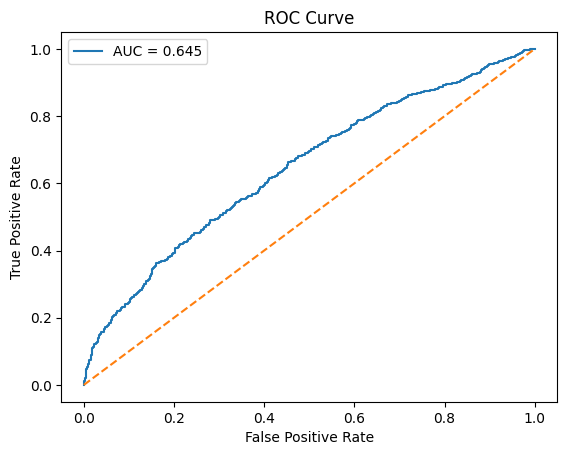

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

model.eval()
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask)

        probs = F.softmax(outputs, dim=1)[:, 1]   # probability of class 1 (fake)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# ---------------------------
# CONFUSION MATRIX
# ---------------------------
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

# ---------------------------
# CLASSIFICATION REPORT
# ---------------------------
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

# ---------------------------
# ROC CURVE
# ---------------------------
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


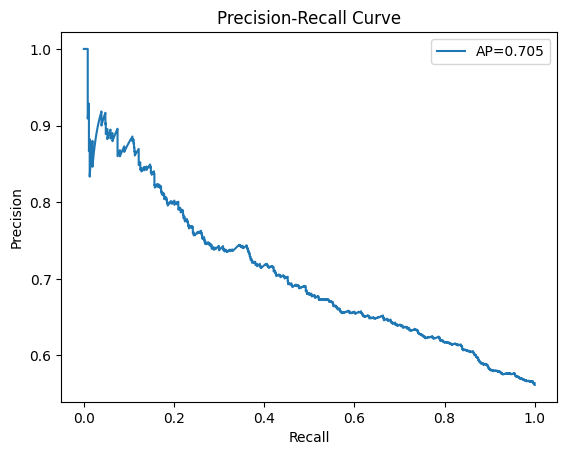

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(all_labels, all_probs)
avg_prec = average_precision_score(all_labels, all_probs)

plt.plot(recall, precision, label=f"AP={avg_prec:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


In [ ]:
import numpy as np

all_probs = np.array(all_probs)
print("Mean probability of correct predictions:", all_probs[np.array(all_preds) == np.array(all_labels)].mean())
print("Mean probability of incorrect predictions:", all_probs[np.array(all_preds) != np.array(all_labels)].mean())


Mean probability of correct predictions: 0.6481578
Mean probability of incorrect predictions: 0.6021701


In [ ]:
misclassified = []
for batch in test_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)

    outputs = model(input_ids, attention_mask)
    _, predicted = torch.max(outputs, 1)

    for i in range(len(labels)):
        if predicted[i] != labels[i]:
            misclassified.append((batch['input_ids'][i], labels[i].item(), predicted[i].item()))


In [ ]:
text = tokenizer.decode(misclassified[0][0])


In [ ]:
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(all_labels, all_preds)
print("MCC:", mcc)


MCC: 0.18466214763005698
